# FallDar Dataset introduction and preprocessing
 
Zheng Yang, Yi Zhang, and Qian Zhang. Rethinking Fall Detection With Wi-Fi. IEEE Transactions on Mobile Computing 22, 10 (Oct. 2023), 6126–6143.


## Introduction

Collected in home environments (five family members) and office settings (two volunteers), this dataset uses the same WiFi devices as the Widar3.0 dataset. It includes 610 fall instances and 2,000 normal instances at home, and 228 fall instances and 504 normal instances in the office, along with 900 synthetic fall instances.

The folder tree is  as follows:

```
.
├── matlab_scripts                       # this i the matlab scripts used to preprocess the raw data
├── raw_data                             # this is the raw data folder  
├── annotations.pkl  # The annotation file generated in the below cells, where we have three columns: 'file_name', 'user', and 'label': 0-> nonfall ,1->fall    
├── Intro_preprocess_vis.ipynb            # this file provide some visulization of the data processing                     
└── README.md                             # instruction on how to process the dataset
```


- Data_Speed_Sequence: 
    - The speed sequence is the motion statistic of the csi data that describes the motion of the person. The calculation method can be found in: F. Zhang et al., "SMARS: Sleep Monitoring via Ambient Radio Signals," in IEEE Transactions on Mobile Computing, vol. 20, no. 1, pp. 217-231, 1 Jan. 2021.
    - The speed sequence is later used to process the raw data.
- matlab_scripts:
    - the matlab scripts are used to preprocess the raw data.
    - all the csi sequence is cut into fixed length: 1500 (1.5 seconds):
        - The non-fall samples are segmented into 1500 length sequences with a 50% overlap.
        - The fall samples are segmented into 1500 length sequences that extract the fall moment and 900 length sequences before and 500 after the fall moment.
- raw_data:
    File name forcmat:
    - zhangyi-1-1-r
    - name-activity-repeat-r


### Create the meta information for the dataset

We will redo the preprocessing of the raw data (with python) and create the meta information (how the data are labeled) for the dataset.


<font color='red'>The meta information is from the experiments recording by the author in matlab_scripts/FallDataset.pdf</font>

In [1]:
# list the forder names in the raw_data folder
import os

raw_data_folders = []
raw_data_root = 'raw_data'
raw_data = os.path.join(os.getcwd(), raw_data_root)
folders = os.listdir(raw_data)
for folder in folders:
    if os.path.isdir(os.path.join(raw_data, folder)):
        raw_data_folders.append(folder)

print(raw_data_folders)

['20200601', '20200706', '20200712', '20200705', '20200623', '20200708', '20200614', '20200713', '20200525', '20200709', '20200526']


The metat information (in metas.csv) from the author is as follows:
```csv
Folder_name,User(s),Nonfall_index,Fall_index
20200525,zhangyi,1:22,Non
20200526,zhangyi,1:5,Non
20200601,bionic,Non,1:100
20200614,bionic,Non,1:2
20200623,zhangyi,1:3,Non
20200705,bionic,Non,1:3
20200706,zhangyi,1:5,Non
20200708,zhangyi,Non,1:2
20200709,"yafei, shengcai, jinlan",Non,1:2
20200712,yafei,1,Non
20200713,"bionic, wanglin",6,1:5
```

Constructing a python dictionary for the meta information

In [2]:
meta_info_dic ={}

meta_info_dic['20200525'] = {
    'user':['zhangyi'],
    'non_fall_index':[i for i in range(1, 23)],
    'fall_index':[],
}

meta_info_dic['20200526'] = {
    'user':['zhangyi'],
    'non_fall_index':[i for i in range(1, 6)],
    'fall_index':[],
}

meta_info_dic['20200601'] = {
    'user':['bionic'],
    'non_fall_index':[],
    'fall_index':[i for i in range(1, 101)],
}


meta_info_dic['20200614'] = {
    'user':['bionic'],
    'non_fall_index':[],
    'fall_index':[i for i in range(1, 3)],
}

meta_info_dic['20200623'] = {
    'user':['zhangyi'],
    'non_fall_index':[i for i in range(1, 4)],
    'fall_index':[],
}

meta_info_dic['20200705'] = {
    'user':['bionic'],
    'non_fall_index':[],
    'fall_index':[i for i in range(1, 4)],
}

meta_info_dic['20200706'] = {
    'user':['zhangyi'],      
    'non_fall_index':[i for i in range(1, 6)],
    'fall_index':[],
}

meta_info_dic['20200708'] = {
    'user':['zhangyi'],      
    'non_fall_index':[],
    'fall_index':[i for i in range(1, 3)],
}

meta_info_dic['20200709'] = {
    'user':['yafei', 'shengcai', 'jinlan'],      
    'non_fall_index':[],
    'fall_index':[i for i in range(1, 3)],
}

meta_info_dic['20200712'] = {
    'user':['yafei'],      
    'non_fall_index':[1],
    'fall_index':[],
}

meta_info_dic['20200713'] = {
    'user':['bionic', 'wanglin'],      
    'non_fall_index':[6],
    'fall_index':[i for i in range(1, 6)],
}

# set the dictionary as a pandas dataframe
# import pandas as pd

# meta_info_df = pd.DataFrame(meta_info_dic)
# meta_info_df = meta_info_df.T
# meta_info_df = meta_info_df.reset_index()
# meta_info_df.columns = ['foder', 'user', 'non_fall_index', 'fall_index']

# print(meta_info_df)


### Building a annotation file based on the meta information for all the samples

In [3]:
failed_files = []

annotations = []
fall_count = 0
non_fall_count = 0  

raw_data_root = 'raw_data'
for folder in raw_data_folders:
    # list all the files in the folder
    files = os.listdir(os.path.join (raw_data_root, folder))
    try:
        meta = meta_info_dic[folder]
        # print(meta)
        for file in files:
            # print(file)
            file_user = file.split('-')[0]
            file_index = int(file.split('-')[1])
            file_repeat_number = int(file.split('-')[2])
            # print(file_user, file_index, file_repeat_number)
            if file_user in meta['user']:
                if file_index in meta['non_fall_index']:
                    annotations.append([os.path.join(raw_data_root, folder, file), file_user ,0])
                    non_fall_count += 1
                elif file_index in meta['fall_index']:
                    annotations.append([os.path.join(raw_data_root, folder, file), file_user ,1])
                    fall_count += 1
                else:
                    failed_files.append(file)
            else:
                failed_files.append(file)
    except:
        print('no meta info for folder:', folder)
        continue

In [4]:
print('fall_count:', fall_count)
print('non_fall_count:', non_fall_count)
print(len(annotations))
for ele in annotations:
    print(ele)

fall_count: 622
non_fall_count: 234
856
['raw_data/20200601/bionic-1-41-r.dat', 'bionic', 1]
['raw_data/20200601/bionic-1-60-r.dat', 'bionic', 1]
['raw_data/20200601/bionic-1-91-r.dat', 'bionic', 1]
['raw_data/20200601/bionic-1-22-r.dat', 'bionic', 1]
['raw_data/20200601/bionic-1-19-r.dat', 'bionic', 1]
['raw_data/20200601/bionic-1-76-r.dat', 'bionic', 1]
['raw_data/20200601/bionic-1-57-r.dat', 'bionic', 1]
['raw_data/20200601/bionic-1-38-r.dat', 'bionic', 1]
['raw_data/20200601/bionic-1-34-r.dat', 'bionic', 1]
['raw_data/20200601/bionic-1-15-r.dat', 'bionic', 1]
['raw_data/20200601/bionic-1-87-r.dat', 'bionic', 1]
['raw_data/20200601/bionic-1-1-r.dat', 'bionic', 1]
['raw_data/20200601/bionic-1-40-r.dat', 'bionic', 1]
['raw_data/20200601/bionic-1-61-r.dat', 'bionic', 1]
['raw_data/20200601/bionic-1-90-r.dat', 'bionic', 1]
['raw_data/20200601/bionic-1-23-r.dat', 'bionic', 1]
['raw_data/20200601/bionic-1-18-r.dat', 'bionic', 1]
['raw_data/20200601/bionic-1-77-r.dat', 'bionic', 1]
['raw_d

In [5]:
print(failed_files)

[]


### Saving the annotation file as a pickle file


In [6]:
# import pickle

# with open('annotations.pkl', 'wb') as f:
#     pickle.dump(annotations, f)


### Loading the data with CSIKit

In [7]:
# loading the annotations
import pickle

with open('annotations.pkl', 'rb') as f:
    annotations = pickle.load(f)

print(annotations)

[['raw_data/20200525/zhangyi-17-2-r.dat', 'zhangyi', 0], ['raw_data/20200525/zhangyi-16-1-r.dat', 'zhangyi', 0], ['raw_data/20200525/zhangyi-5-2-r.dat', 'zhangyi', 0], ['raw_data/20200525/zhangyi-20-1-r.dat', 'zhangyi', 0], ['raw_data/20200525/zhangyi-7-2-r.dat', 'zhangyi', 0], ['raw_data/20200525/zhangyi-12-2-r.dat', 'zhangyi', 0], ['raw_data/20200525/zhangyi-10-1-r.dat', 'zhangyi', 0], ['raw_data/20200525/zhangyi-8-1-r.dat', 'zhangyi', 0], ['raw_data/20200525/zhangyi-4-2-r.dat', 'zhangyi', 0], ['raw_data/20200525/zhangyi-6-2-r.dat', 'zhangyi', 0], ['raw_data/20200525/zhangyi-21-2-r.dat', 'zhangyi', 0], ['raw_data/20200525/zhangyi-1-1-r.dat', 'zhangyi', 0], ['raw_data/20200525/zhangyi-10-2-r.dat', 'zhangyi', 0], ['raw_data/20200525/zhangyi-21-1-r.dat', 'zhangyi', 0], ['raw_data/20200525/zhangyi-13-1-r.dat', 'zhangyi', 0], ['raw_data/20200525/zhangyi-14-1-r.dat', 'zhangyi', 0], ['raw_data/20200525/zhangyi-16-2-r.dat', 'zhangyi', 0], ['raw_data/20200525/zhangyi-2-2-r.dat', 'zhangyi', 0]

In [8]:
anno = annotations[100]
print(anno)

file_path = anno[0] 
print(file_path)
label = anno[2]
print(label)


['raw_data/20200713/bionic-3-10-r.dat', 'bionic', 1]
raw_data/20200713/bionic-3-10-r.dat
1


In [9]:
# loading the raw data

from CSIKit.reader import IWLBeamformReader

my_reader = IWLBeamformReader()
csi_data = my_reader.read_file(file_path)
print(type(csi_data))


meta_data = csi_data.get_metadata()

# the meta_data is a CSIMetadata object, print all the attributes
print("chipset: ", meta_data.chipset)
print("backend: ", meta_data.backend)
print("bandwidth: ", meta_data.bandwidth)
print("antenna_config: ", meta_data.antenna_config)
print("frames: ", meta_data.frames)
print("subcarriers: ", meta_data.subcarriers)
print("time_length: ", meta_data.time_length)
print("average_sample_rate: ", meta_data.average_sample_rate)
print("average_rssi: ", meta_data.average_rssi)
print("csi_shape: ", meta_data.csi_shape)

<class 'CSIKit.csi.csidata.CSIData'>
chipset:  Intel IWL5300
backend:  Linux 802.11n CSI Tool
bandwidth:  20
antenna_config:  3 Rx, 1 Tx
frames:  2751
subcarriers:  30
time_length:  2.752999999999986
average_sample_rate:  999.3
average_rssi:  39.1
csi_shape:  (30, 3, 1)


csi_matrix:  (2751, 30, 3, 1)
one element in csi_matrix:  [0.-1.j]
no_frames:  2751
no_subcarriers:  30


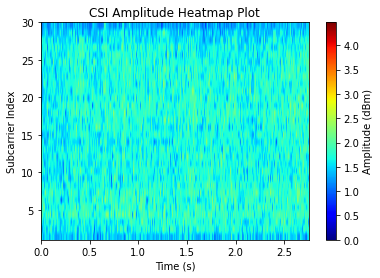

In [10]:
import itertools
from typing import Tuple
import numpy as np
from CSIKit.tools.batch_graph import BatchGraph

def get_CSI(csi_data: 'CSIData', squeeze_output: bool = False) -> Tuple[np.array, int, int]:
    frames = csi_data.frames
    csi_shape = frames[0].csi_matrix.shape

    no_frames = len(frames)
    no_subcarriers = csi_shape[0]

    # Matrices should be Frames * Subcarriers * Rx * Tx.
    # Single Rx/Tx streams should be squeezed.
    if len(csi_shape) == 3:
        # Intel data comes as Subcarriers * Rx * Tx.
        no_rx_antennas = csi_shape[1]
        no_tx_antennas = csi_shape[2]
    elif len(csi_shape) == 2 or len(csi_shape) == 1:
        # Single antenna stream.
        no_rx_antennas = 1
        no_tx_antennas = 1
    else:
        # Error. Unknown CSI shape.
        print("Error: Unknown CSI shape.")

    csi = np.zeros((no_frames, no_subcarriers, no_rx_antennas, no_tx_antennas), dtype=complex)
    ranges = itertools.product(*[range(n) for n in [no_frames, no_subcarriers, no_rx_antennas, no_tx_antennas]])
    is_single_antenna = no_rx_antennas == 1 and no_tx_antennas == 1

    drop_indices = []
    for frame, subcarrier, rx_antenna_index, tx_antenna_index in ranges:
        frame_data = frames[frame].csi_matrix
        if subcarrier >= frame_data.shape[0]:
            # Inhomogenous component
            # Skip frame for now. Need a better method soon.
            continue

        subcarrier_data = frame_data[subcarrier]
        if subcarrier_data.shape != (no_rx_antennas, no_tx_antennas) and not is_single_antenna:
            if rx_antenna_index >= subcarrier_data.shape[0] or tx_antenna_index >= subcarrier_data.shape[1]:
                # Inhomogenous component
                # Skip frame for now. Need a better method soon.
                drop_indices.append(frame)
                continue
        csi[frame][subcarrier][rx_antenna_index][tx_antenna_index] = subcarrier_data if is_single_antenna else \
            subcarrier_data[rx_antenna_index][tx_antenna_index]  
    csi = np.delete(csi, drop_indices, 0)
    csi_data.timestamps = [x for i, x in enumerate(csi_data.timestamps) if i not in drop_indices]
    if squeeze_output:
        csi = np.squeeze(csi)
    return (csi, no_frames, no_subcarriers)


csi_matrix1, no_frames1, no_subcarriers1 = get_CSI(csi_data)
print("csi_matrix: ", csi_matrix1.shape)
print('one element in csi_matrix: ', csi_matrix1[0][0][0])
print("no_frames: ", no_frames1)
print("no_subcarriers: ", no_subcarriers1)


csi_matrix_first = csi_matrix1[:, :, 0, 0]
csi_matrix_squeezed = np.abs(np.squeeze(csi_matrix_first))
BatchGraph.plot_heatmap(csi_matrix_squeezed, csi_data.timestamps)

In [11]:
# Preprocessing the csi matrix based on the method in Widar3 paper and calculate the motion statistics
from scipy.signal import butter, filtfilt

def nextpow2(i):
    return np.ceil(np.log2(i))
def autocorr(x):
    nFFT = int(2**(nextpow2(len(x))+1))
    F = np.fft.fft(x,nFFT)
    F = F*np.conj(F)
    acf = np.fft.ifft(F)
    acf = acf[0:len(x)] # Retain nonnegative lags
    acf = np.real(acf)
    acf = acf/acf[0] # Normalize
    return acf

def preprocess_CSI(csi_matrix: np.array, csi_sample_rate: int = 1000):
    '''ArithmeticError
    Preprocesses the CSI matrix by applying phase cleaning (Widar3.0) and a lowpass and highpass filter.
    Then, calculates the motion statistics.
    The shape of the CSI matrix (complex-valued) should be Frames (time dimension) * Subcarriers * Rx * Tx.
    Returns the processed CSI matrix and the motion statistics.
    '''
    # define the lowpass and highpass filter
    half_rate = csi_sample_rate / 2
    uppe_orde = 6
    uppe_stop = 60
    if uppe_stop > half_rate:
        uppe_stop = half_rate - 1
    lowe_orde = 3
    lowe_stop = 2
    lu, ld = butter(uppe_orde, uppe_stop / half_rate, 'low')  
    hu, hd = butter(lowe_orde, lowe_stop / half_rate, 'high')
    
    num_frames, num_subcarriers, num_rx, num_tx = csi_matrix.shape
    print("num_frames: ", num_frames)
    print("num_subcarriers: ", num_subcarriers)
    print("num_rx: ", num_rx)
    print("num_tx: ", num_tx)
    # phase cleaning
    if num_rx == 1:
        cleaned_csi = csi_matrix
    elif num_rx == 2:
        cleaned_csi = np.zeros((num_frames, num_subcarriers, 1, num_tx), dtype=complex)
        cleaned_csi = csi_matrix[:, :, 0, :] * np.conj(csi_matrix[:, :, 1, :])
    else:
        cleaned_csi = np.zeros((num_frames, num_subcarriers, num_rx, num_tx), dtype=complex)
        for i in range(num_rx):
            cleaned_csi[:, :, i, :] = csi_matrix[:, :, i, :] * np.conj(csi_matrix[:, :, (i + 1)%num_rx, :])

    # calculate the motion statistics
    
    # print("csi shape")
    # for sliding window size = 500, step = 100,
    WIN_SIZE = 500
    WIN_STEP = 100
    win_start = list(range(0, num_frames-WIN_SIZE, WIN_STEP))
    win_num = len(win_start)
    motion_statistics = np.zeros((win_num, num_subcarriers, num_rx, num_tx))
    for ti, w_start in enumerate(win_start):
        for j in range(num_rx):
            for k in range(num_tx):
                win_range = range(w_start, w_start+WIN_SIZE)
                csi_jk = cleaned_csi[win_range, :, j, k]
                csi_jk_amp = np.abs(csi_jk)
                # L2 norm across subcarriers
                time_len = csi_jk_amp.shape[0]
                csi_jk_norm = [csi_jk_amp[t, :] / np.linalg.norm(csi_jk_amp[t, :]) for t in range(time_len)]
                csi_jk_norm = np.array(csi_jk_norm)
                # print("csi_jk_norm shape: ", csi_jk_norm.shape)
                # Remove DC
                for i in range(num_subcarriers):
                    this_csi = csi_jk_norm[:, i]
                    # remove DC
                    this_csi = this_csi - np.mean(this_csi)
                    # 
                    # motion_statistics[i, j, k] = (np.dot(np.insert(this_csi, 0, 0), np.append(this_csi, 0))) / np.dot(this_csi, this_csi)
                    this_acf = autocorr(this_csi)
                    motion_statistics[ti, i, j, k] = this_acf[1]
                    
     # apply the lowpass filter
    for i in range(num_subcarriers):
        for j in range(num_rx):
            for k in range(num_tx):
                cleaned_csi[:, i, j, k] = filtfilt(lu, ld, cleaned_csi[:, i, j, k])
    # apply the highpass filter
    for i in range(num_subcarriers):
        for j in range(num_rx):
            for k in range(num_tx):
                cleaned_csi[:, i, j, k] = filtfilt(lu, ld, cleaned_csi[:, i, j, k])

    return cleaned_csi, motion_statistics

In [12]:
cleaned_csi, motion_statistics = preprocess_CSI(csi_matrix1)

print("cleaned_csi: ", cleaned_csi.shape)
print("motion_statistics: ", motion_statistics.shape)

num_frames:  2751
num_subcarriers:  30
num_rx:  3
num_tx:  1


cleaned_csi:  (2751, 30, 3, 1)
motion_statistics:  (23, 30, 3, 1)


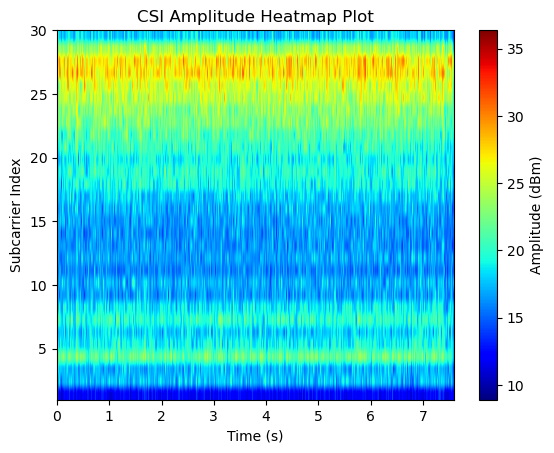

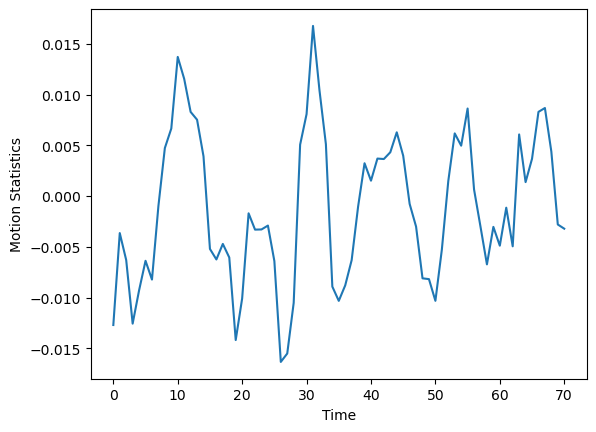

In [36]:
csi_matrix_first = cleaned_csi[:, :, 0, 0]
csi_matrix_squeezed = np.abs(np.squeeze(csi_matrix_first))
BatchGraph.plot_heatmap(csi_matrix_squeezed, csi_data.timestamps)



motion_s = motion_statistics[:, :, 0, 0]
ms_mean = np.mean(motion_s, axis=1)

motion_s_squeezed = np.abs(np.squeeze(ms_mean))

import matplotlib.pyplot as plt
# reverse motion_s_squeezed to match the subcarrier index
plt.plot(ms_mean)
plt.xlabel('Time')
plt.ylabel('Motion Statistics')
# plt.gca().invert_xaxis()
plt.show()